In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

In [76]:
Path("../figures").mkdir(exist_ok=True)
Path("../figures/eda").mkdir(exist_ok=True)

In [77]:
df = pd.read_csv("../data/hour.csv")
df.rename(columns={'cnt':'demand'}, inplace=True)
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,demand
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [78]:
df.shape

(17379, 17)

In [79]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
demand        0
dtype: int64

In [80]:
# unscale for plotting

df["temp"] = df["temp"]*47-8
df["atemp"] = df["atemp"]*66-16
df["hum"] = df["hum"]*100
df["windspeed"] = df["windspeed"]*67

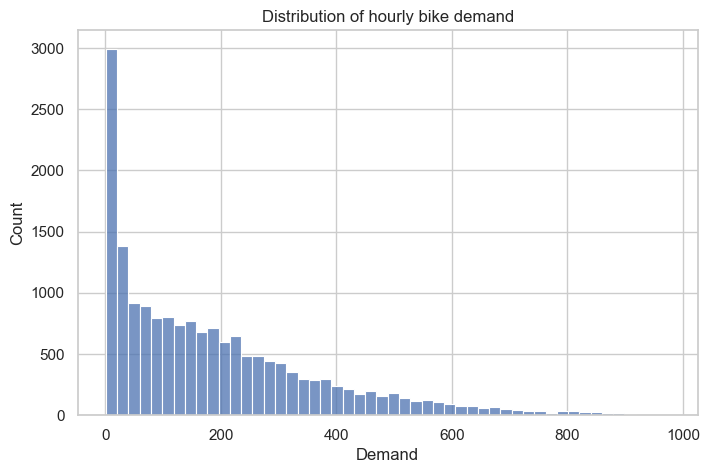

In [81]:
plt.figure(figsize=(8,5))
sns.histplot(df["demand"], bins=50)
plt.title("Distribution of hourly bike demand")
plt.xlabel("Demand")
plt.show()

Seperate predictors into numerical, categorical, cyclical

In [82]:
numerical_cols = ["temp", "atemp", "hum", "windspeed"]
categorical_cols = ["season", "weathersit", "weekday", "workingday", "holiday"]
cyclical_cols = ["mnth", "hr"]

Categorical variables

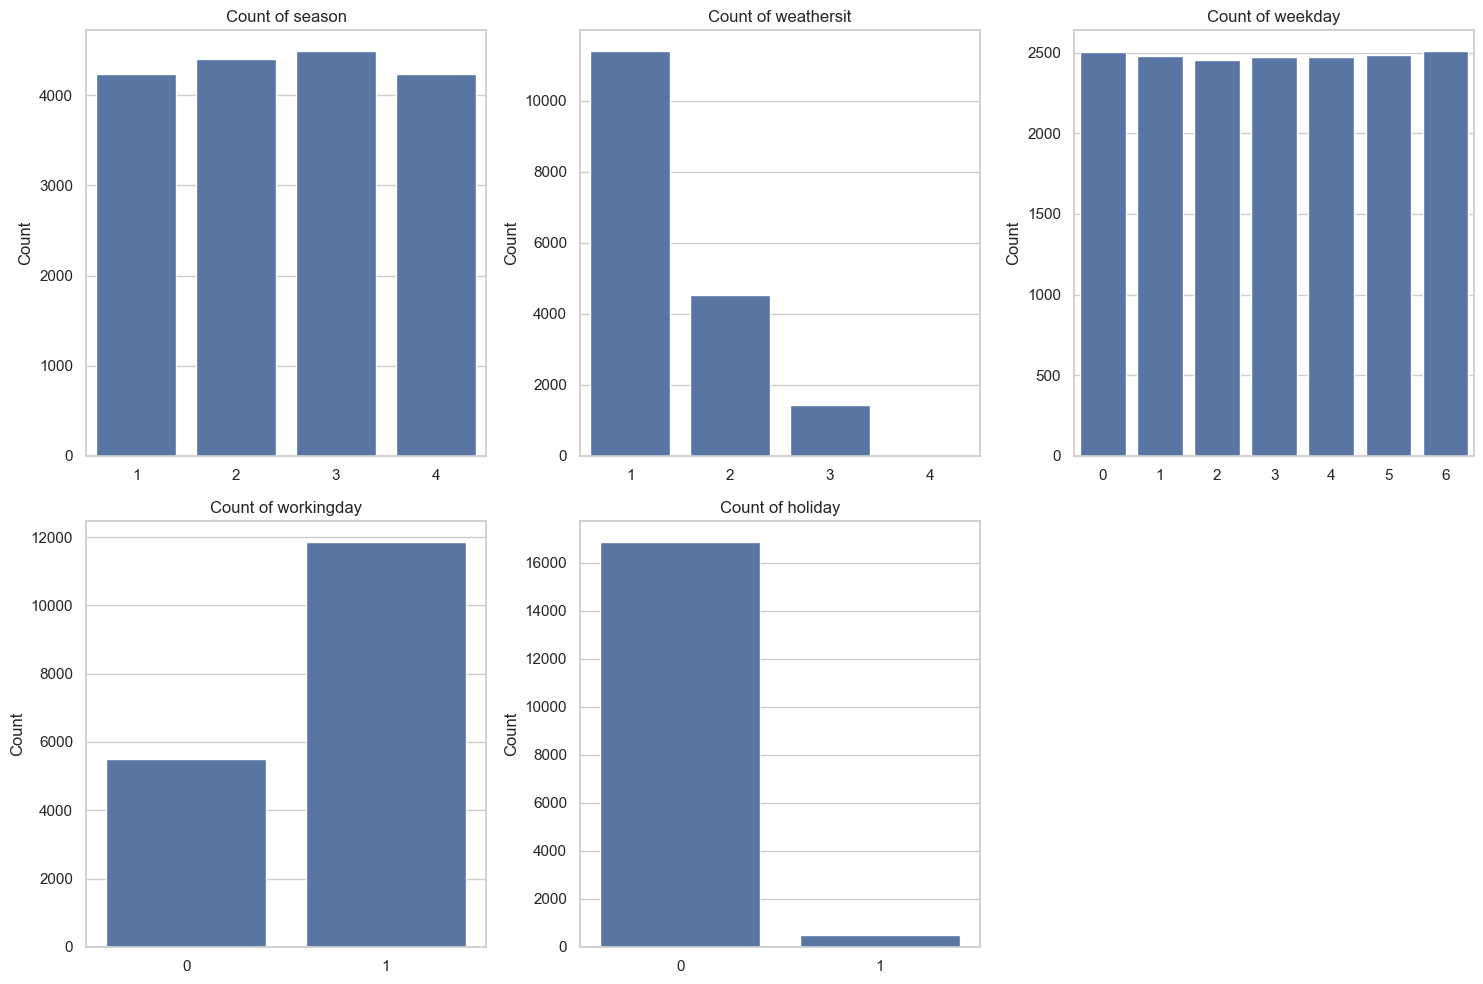

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

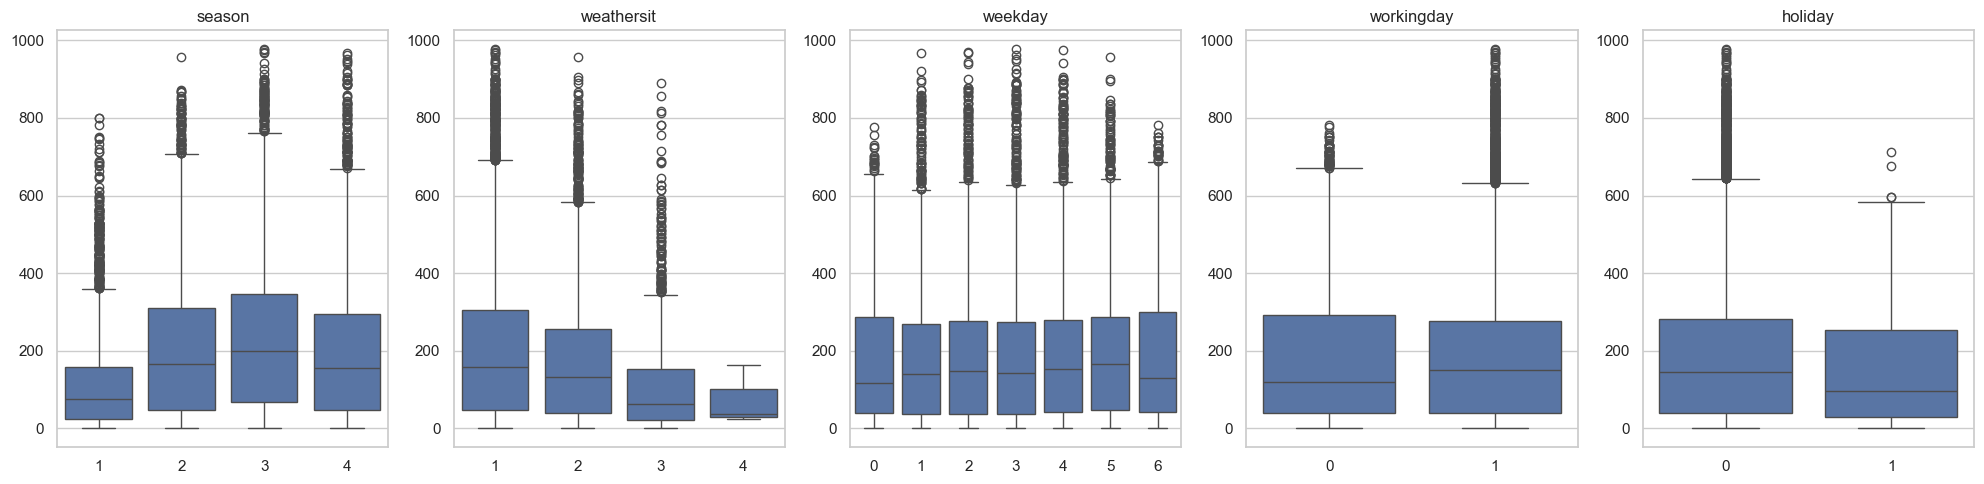

In [84]:
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(20,5))

for i, col in enumerate(categorical_cols):
    sns.boxplot(x=col, y="demand", data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

Cyclical variables

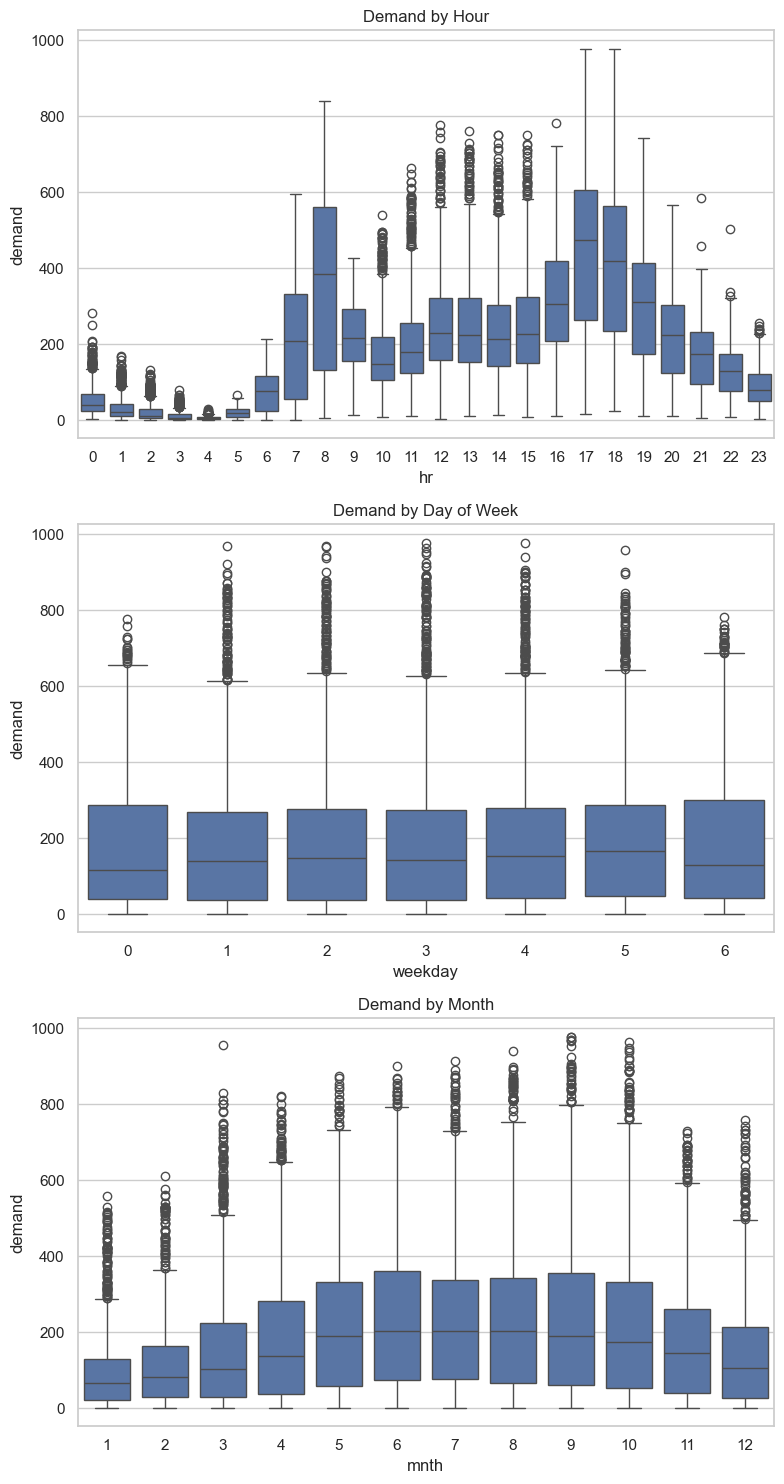

In [85]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharey=True)

# Demand by hour
sns.boxplot(x="hr", y="demand", data=df, ax=axes[0])
axes[0].set_title("Demand by Hour")

# Demand by weekday
sns.boxplot(x="weekday", y="demand", data=df, ax=axes[1])
axes[1].set_title("Demand by Day of Week")

# Demand by month
sns.boxplot(x="mnth", y="demand", data=df, ax=axes[2])
axes[2].set_title("Demand by Month")

plt.tight_layout()
plt.show()

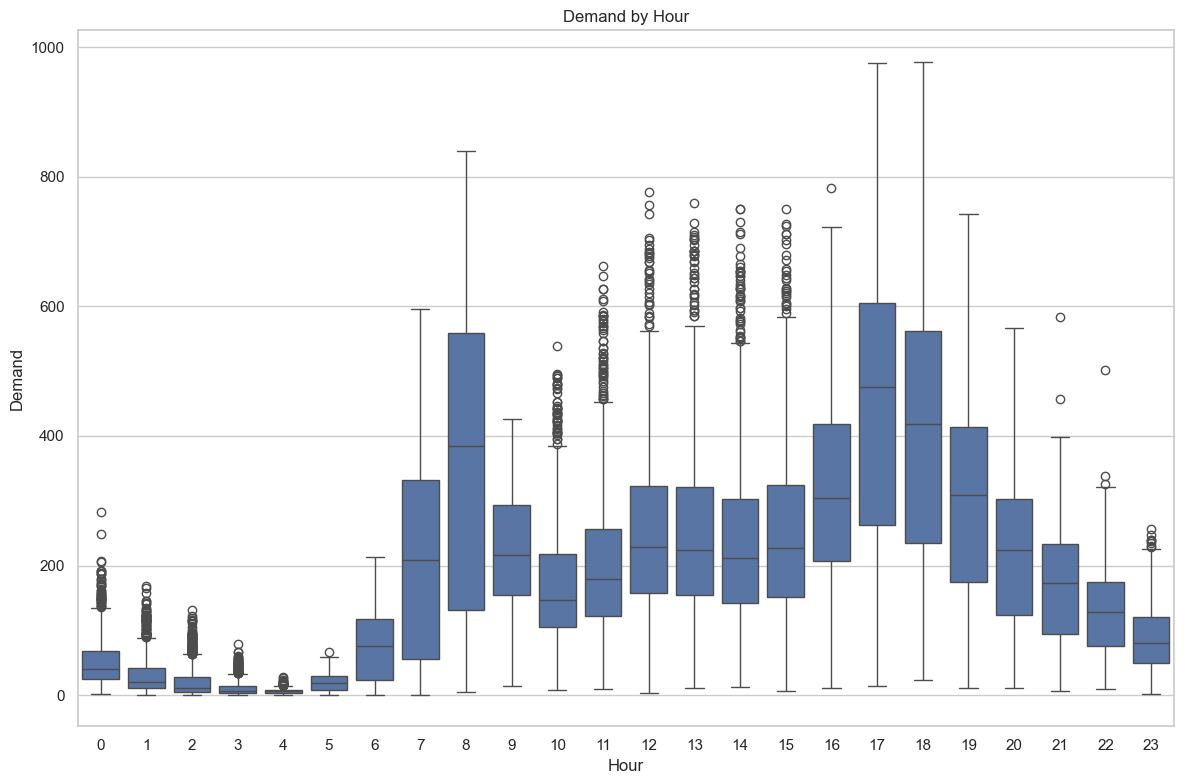

In [86]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    x="hr",
    y="demand",
    data=df,
)
plt.title("Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Demand")
plt.tight_layout()
plt.savefig(
    "../figures/eda/demand_by_hour.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Numerical variables

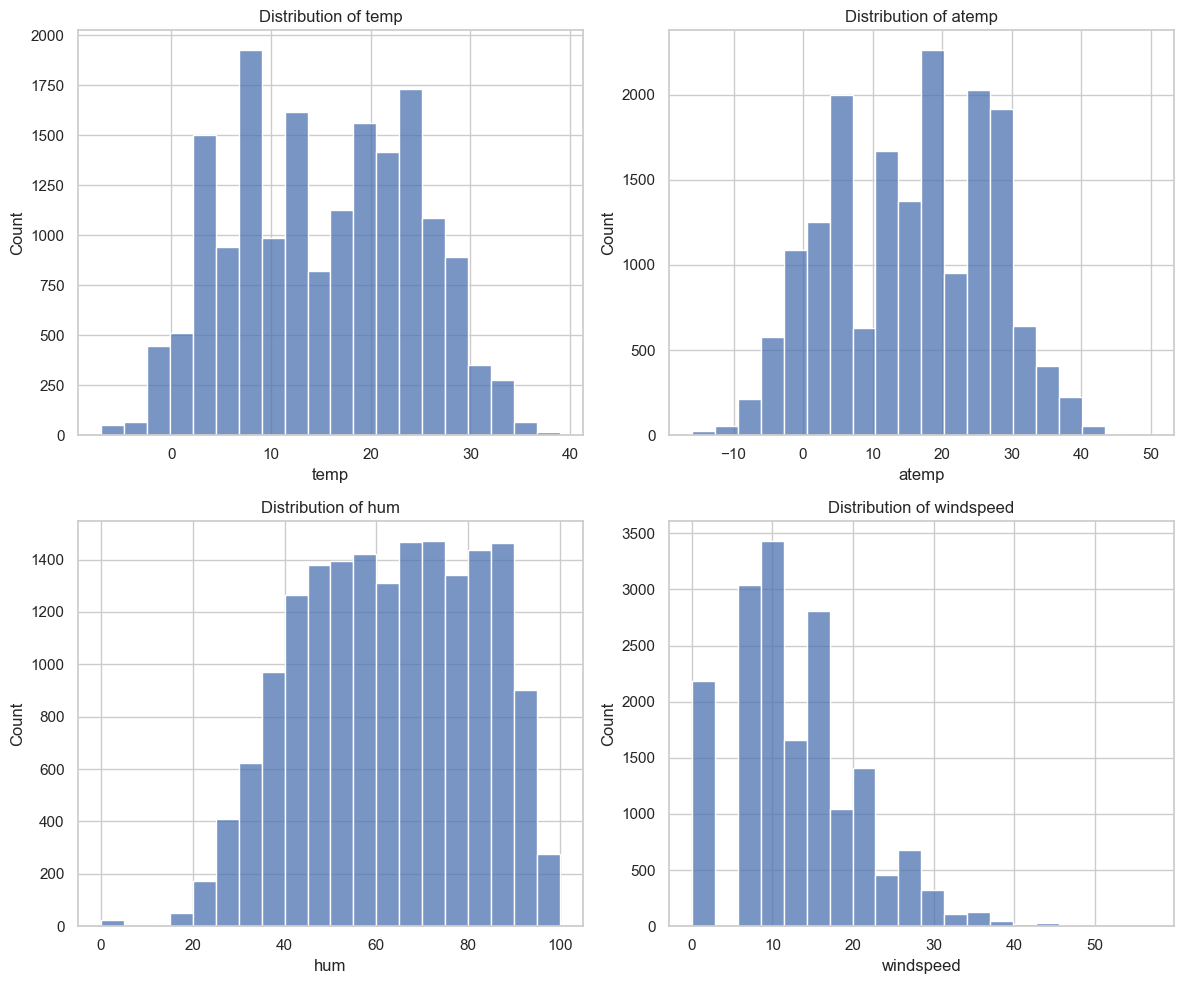

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, bins=20, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

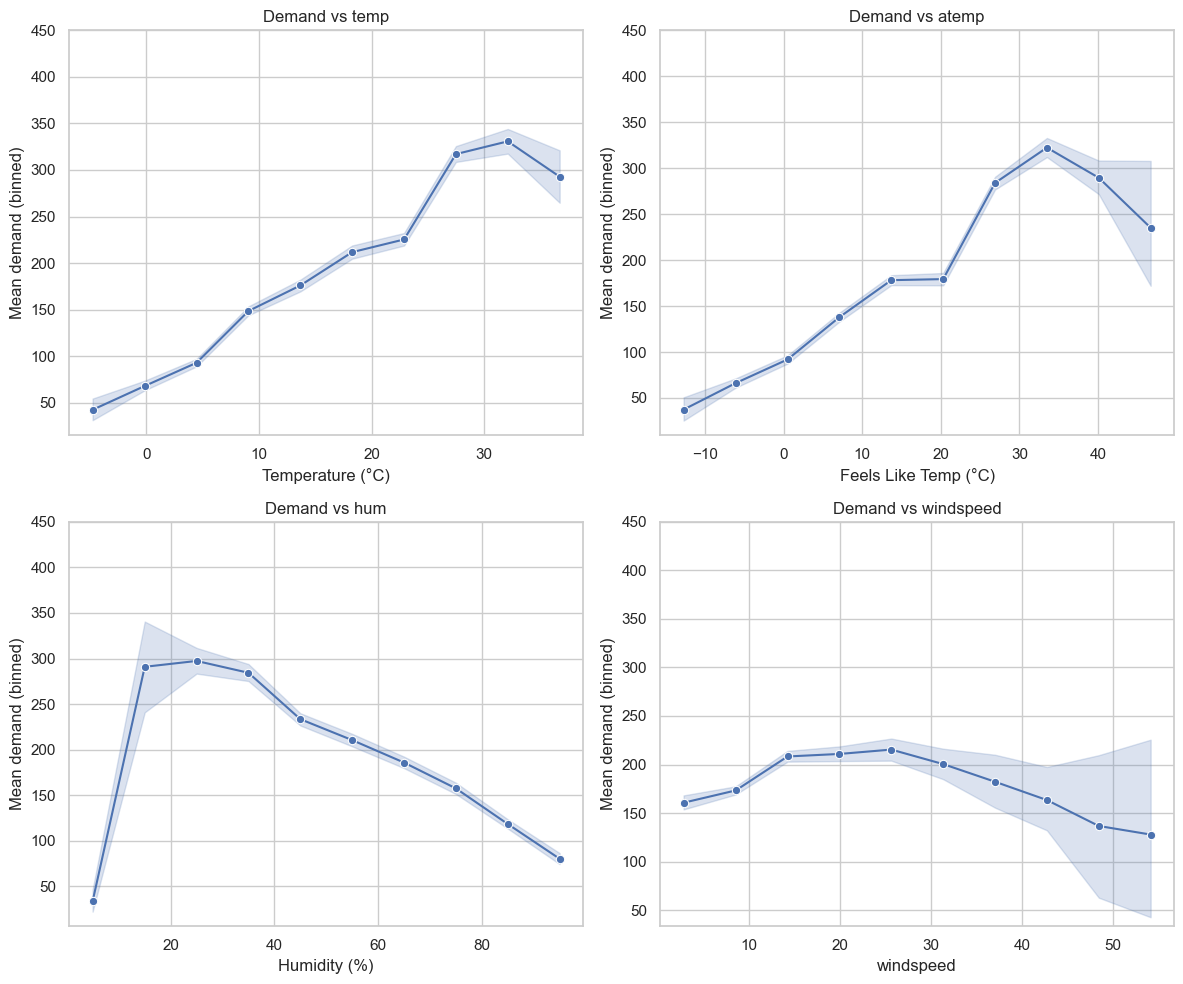

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    
    if col == "temp":
        xlabel = "Temperature (°C)"
    elif col == "atemp":
        xlabel = "Feels Like Temp (°C)"
    elif col == "hum":
        xlabel = "Humidity (%)"
    else:
        xlabel = col

    bins = pd.cut(df[col], bins=10)
    midpoints = bins.map(lambda b: b.mid)
    sns.lineplot(x=midpoints, y=df["demand"], estimator="mean", marker="o", ax=axes[i])
    
    axes[i].set_title(f"Demand vs {col}")
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel("Mean demand (binned)")
    axes[i].set_ylim(top=450)

plt.tight_layout()
plt.show()

In [89]:
col = "windspeed"
bins = pd.cut(df[col], bins=10)
midpoints = bins.map(lambda b: b.mid)
plt.figure(figsize=(6, 5))
sns.lineplot(
    x=midpoints,
    y=df["demand"],
    estimator="mean",
    marker="o",
)
plt.title("Demand vs Windspeed")
plt.xlabel("Windspeed")
plt.ylabel("Mean demand (binned)")
plt.ylim(top=450)
plt.tight_layout()
plt.savefig(
    "../figures/eda/demand_vs_windspeed.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()

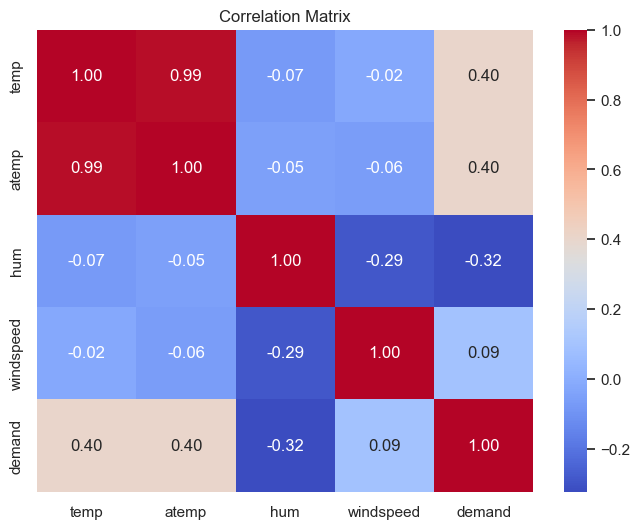

In [90]:
cols = numerical_cols + ["demand"]

plt.figure(figsize=(8,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig(
    "../figures/eda/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Key Observations

- No missing observations
- The demand by hour shows sharp peaks (commuting times).
    -> Will be suitable to one-hot encode and not try a smooth fit
- Colinear predictors temp and atemp
    -> Drop one or regularization to stabilize model coefficients
- Most numeric predictions show linear-ish relationship to demand
- Windspeed shows more of parabolic relationship
    -> Windspeed^2 may be suitable to add